![Image in a markdown cell](https://cursos.utnba.centrodeelearning.com/pluginfile.php/1/theme_space/customlogo/1738330016/Logo%20UTN%20Horizontal.png)



# **Diplomado de Ciencia de Datos y Análisis Avanzado**
# **Unidad 9: Trabajo Practico Final.**

---

# **Proyecto: Detección temprana de transacciones potencialmente ilícitas (Anti-Money Laundering, AML)**

## **Curso:** Diplomado en Ciencia de Datos

# **Nombres de los Miembros del Equipo:**
###    Tomás Sezaro
###    Cecilia Islas
###    Noelia Frias
###    Nicolas Gottig
###    Laura Marquez


# **Objetivo:**
## Las entidades financieras están obligadas por regulación a monitorear operaciones sospechosas para prevenir actividades como lavado de dinero, financiamiento ilícito o fraude estructurado. La detección manual es costosa, lenta y propensa a errores, por lo que el uso de modelos de machine learning resulta clave para automatizar el análisis y priorizar alertas.


---

# 1. **Propuesta de Dataset y definición del problema**

## El IBM Transactions for Anti Money Laundering (AML) es un conjunto de datos transaccionales financieros generado por IBM mediante el simulador AMLSim. El dataset replica el funcionamiento de un sistema bancario real, incluyendo millones de transacciones entre cuentas, distintos formatos de pago (transferencias ACH, wire, criptomonedas, etc.), monedas y registros temporales.
## El conjunto de datos está compuesto principalmente por dos archivos complementarios en formato CSV:
## •	Un archivo de transacciones, donde cada registro representa una operación financiera individual e incluye información como fecha y hora, cuenta origen, cuenta destino, monto, formato de pago y una etiqueta binaria que indica si la transacción está asociada a un intento de lavado de dinero.
## •	Un archivo de cuentas, que contiene información estructural adicional sobre las cuentas involucradas, permitiendo enriquecer el análisis mediante la integración de variables contextuales.
## La combinación de ambos archivos permite desarrollar un análisis más profundo, integrando características transaccionales y estructurales del sistema financiero simulado.


---

# 2.1 **Contexto del Dataset y problema a resolver**

## Las instituciones financieras procesan millones de transacciones diariamente. Entre ellas, una proporción muy baja puede estar vinculada a actividades ilícitas. Detectarlas correctamente es crítico, ya que:
## •	No detectar una operación ilícita implica riesgo regulatorio y financiero.
## •	Detectar falsamente operaciones legítimas genera fricción con clientes y sobrecarga operativa.
## El desafío radica en identificar patrones complejos en grandes volúmenes de datos altamente desbalanceados, donde las transacciones ilícitas representan una fracción mínima del total.


---

# 2.2 **Conjunto de datos utilizados**

## El dataset se encuentra a nivel transaccional, donde cada registro representa una operación financiera individual entre dos cuentas dentro de un sistema bancario simulado.

## El conjunto de datos está compuesto por dos archivos principales:
## •	**HI-Small_Trans.csv**: contiene la información detallada de cada transacción.
## •	**HI-Small_accounts.csv**: contiene información estructural adicional sobre las cuentas involucradas.


---

# 2.3 **Descripción de las variables del Dataset**

## Las principales variables utilizadas en el análisis son:

## **Variables del archivo de transacciones**
### **Timestamp**: fecha y hora en la que se realizó la transacción.
### **From Account**: identificador de la cuenta origen.
### **To Account**: identificador de la cuenta destino.
### **From Bank / To Bank**: entidad bancaria asociada a cada cuenta.
### **Amount Paid**: monto enviado en la transacción.
### **Amount Received**: monto recibido (puede diferir por comisiones o conversión).
### **Currency**: moneda de la operación.
### **Payment Format**: tipo de transacción (transferencia electrónica, ACH, wire, etc.).
### **Is Laundering**: variable binaria objetivo (0 = operación legítima, 1 = operación asociada a lavado de dinero).

## **Variables del archivo de cuentas**
### **Account ID**: identificador único de la cuenta.
### **Bank ID**: entidad bancaria a la que pertenece la cuenta.
### **Account Type / Balance (según versión)**: características estructurales de la cuenta.

## A partir de estas variables se construye el problema de negocio, cuyo objetivo es predecir la probabilidad de que una transacción esté asociada a actividades ilícitas, utilizando información transaccional y estructural.

---

# 2.4 **Preparación de los datos**

## Con el objetivo de construir un modelo de clasificación supervisada para la detección de transacciones asociadas a lavado de dinero, se realizaron tareas de limpieza, transformación y adecuación del dataset.

## En primer lugar, Se convirtió la variable Timestamp a formato datetime para permitir el análisis temporal y la generación de variables derivadas. Se verificó la existencia de valores faltantes, registros duplicados y posibles inconsistencias en los montos transferidos, asegurando la calidad y coherencia de la información antes del modelado.

## Dado el volumen del dataset (millones de registros), también se implementaron medidas orientadas a la eficiencia computacional. Se optimizaron los tipos de datos, convirtiendo variables categóricas como Payment Format, Currency y Bank IDs a tipo category, y la variable objetivo Is Laundering a tipo numérico reducido (int8). Asimismo, se monitoreó el consumo de memoria mediante memory_usage="deep", logrando una reducción significativa del uso de recursos y facilitando el procesamiento en entorno local.

## Además, las variables categóricas fueron codificadas adecuadamente para su utilización en modelos de machine learning, asegurando compatibilidad y estabilidad en las etapas posteriores de entrenamiento y validación.

---

# 2.5 **Feature engineering**

## Con el objetivo de capturar patrones de comportamiento transaccional relevantes para la detección de lavado de dinero, se generaron nuevas variables derivadas a partir de la información original del dataset:

### **Hora del día y día de la semana de la transacción**: Se extrajeron componentes temporales a partir de la variable Timestamp, permitiendo identificar posibles patrones horarios o concentraciones atípicas de actividad.

### **Log(Amount Paid)**: Se aplicó una transformación logarítmica al monto transferido con el fin de reducir la asimetría en la distribución de los valores monetarios y mejorar la estabilidad de los modelos, especialmente aquellos sensibles a escalas.

### **Indicador de transacción entre bancos distintos**: Se construyó una variable binaria que identifica si la transacción ocurre entre entidades bancarias diferentes, dado que las transferencias interbancarias pueden presentar dinámicas distintas a las internas.

### **Indicador de auto-transferencia**: Se generó una variable que señala si la cuenta origen y destino coinciden, permitiendo detectar comportamientos potencialmente atípicos o estructurados.

### **Codificación del formato de pago**: La variable Payment Format fue transformada adecuadamente para su utilización en modelos de machine learning, preservando información sobre el canal utilizado en la operación.

### **Número acumulado de transacciones previas por cuenta**: Se incorporó una variable que captura el volumen histórico de operaciones asociadas a cada cuenta, permitiendo contextualizar el comportamiento transaccional dentro de su dinámica previa.

---

# 3. **Métrica de evaluación**

## Dado que el problema corresponde a una clasificación binaria altamente desbalanceada (las transacciones ilícitas representan una proporción reducida del total), la selección de métricas es crítica. Las métricas utilizadas para evaluar el desempeño de los modelos son:

## **ROC-AUC**: Metrica principal que consideraré. Mide la capacidad discriminativa del modelo a través de distintos umbrales de decisión, permitiendo comparar modelos independientemente del threshold específico.

## **Recall (Sensibilidad)**: Mide la proporción de transacciones ilícitas correctamente identificadas.Es una métrica clave desde la perspectiva regulatoria, ya que minimizar falsos negativos reduce el riesgo de no detectar operaciones ilícitas.

## **Precision**: Indica la proporción de transacciones clasificadas como ilícitas que realmente lo son. Es relevante para evitar una sobrecarga operativa derivada de falsos positivos.

## **F1-Score**: Promedio armónico entre Precision y Recall, útil para evaluar el balance global del modelo en contextos desbalanceados.

## **PR-AUC (Precision-Recall AUC)**: Particularmente adecuada en datasets desbalanceados, ya que se enfoca en el desempeño sobre la clase minoritaria.

## El uso conjunto de estas métricas permite realizar una evaluación robusta del desempeño del modelo, considerando tanto impacto operativo como riesgo financiero.

---

# 4.1 **Decisiones Iniciales**

## Previo a la manipulación de los datos, se definieron una serie de decisiones estratégicas y metodológicas que orientan el desarrollo del proyecto y aseguran coherencia técnica en las etapas posteriores. En primer lugar, se estableció como objetivo principal la detección temprana de transacciones potencialmente asociadas a lavado de dinero, abordando el problema como una clasificación binaria supervisada, donde la variable objetivo es **Is Laundering** (0 = operación legítima, 1 = operación ilícita). A diferencia de enfoques simplificados basados únicamente en información transaccional, se decidió trabajar con la integración de ambos archivos disponibles en el dataset. De esta forma garantizamos utilizar información que contiene el detalle operativo de cada movimiento financiero, y la vez, obtener información estructural adicional sobre las entidades involucradas.La integración de ambas fuentes permite enriquecer el análisis mediante la construcción de variables derivadas que capturen no solo el comportamiento individual de cada transacción, sino también patrones históricos y estructurales asociados a las cuentas.

## Si bien el dataset contiene información temporal, el período disponible es reducido, por lo que no resulta adecuado para un análisis de series de tiempo o forecasting. En consecuencia, el componente temporal se incorpora únicamente como variable explicativa dentro del modelo de clasificación. 

## Finalmente, se optó por utilizar la totalidad del período disponible en el dataset seleccionado, garantizando consistencia temporal y representatividad estadística del fenómeno de estudio. Estas definiciones iniciales condicionan la estrategia de preparación de datos, el diseño de variables y la selección posterior de modelos, asegurando alineación entre el problema de negocio y el enfoque analítico adoptado.

---

# 4.2 Ingesta y entendimiento del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,precision_recall_curve,roc_curve,f1_score,auc, precision_score, recall_score
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

In [2]:
# Cargo dataset
trans_path = "data/HI-Small_Trans.csv"
accounts_path = "data/HI-Small_accounts.csv"

print("Cargando cuentas...")
df_accounts = pd.read_csv(accounts_path)

print("Cargando transacciones...")
df_trans = pd.read_csv(trans_path)

Cargando cuentas...
Cargando transacciones...


In [3]:
print("Transacciones:", df_trans.shape)
print("Cuentas:", df_accounts.shape)

Transacciones: (5078345, 11)
Cuentas: (518581, 5)


In [4]:
# Vista general
df_trans.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [5]:
df_accounts.head()

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889


In [6]:
# Tipos de datos y nulos
df_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [7]:
df_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Bank Name       518581 non-null  object
 1   Bank ID         518581 non-null  int64 
 2   Account Number  518581 non-null  object
 3   Entity ID       518581 non-null  object
 4   Entity Name     518581 non-null  object
dtypes: int64(1), object(4)
memory usage: 19.8+ MB


In [8]:
# Estadísticas básicas
df_trans.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06
mean,4.573057e+04,6.574456e+04,5.988726e+06,4.509273e+06,1.019427e-03
std,8.176562e+04,8.409299e+04,1.037183e+09,8.697728e+08,3.191219e-02
min,1.000000e+00,1.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,1.190000e+02,4.259000e+03,1.833700e+02,1.844800e+02,0.000000e+00
50%,9.679000e+03,2.156800e+04,1.411010e+03,1.414540e+03,0.000000e+00
75%,2.862800e+04,1.223320e+05,1.234627e+04,1.229784e+04,0.000000e+00
max,3.563030e+05,3.562940e+05,1.046302e+12,1.046302e+12,1.000000e+00


In [9]:
df_accounts.describe()

,Bank ID
count,518581.000000
mean,103425.510831
std,121479.549761
min,1.000000
25%,11107.000000
50%,32014.000000
75%,217096.000000
max,356303.000000


In [10]:
# Rango temporal del dataset
df_trans["Timestamp"].min(), df_trans["Timestamp"].max()

('2022/09/01 00:00', '2022/09/18 16:18')

In [11]:
# Cantidad de valores nulos por columna
df_trans.isna().sum().sort_values(ascending=False)

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [12]:
df_accounts.isna().sum().sort_values(ascending=False)

Bank Name         0
Bank ID           0
Account Number    0
Entity ID         0
Entity Name       0
dtype: int64

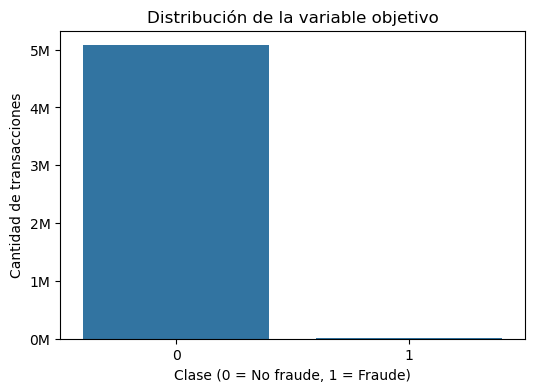

In [13]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Is Laundering', data=df_trans)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase (0 = No fraude, 1 = Fraude)")
plt.ylabel("Cantidad de transacciones")

# Formato eje Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1_000_000)}M'))

plt.show()

#### No se observan valores nulos en ambas variables. Vemos diferentes tipos de datos.

---

# 4.3 Preparación, Optimización, Limpieza y transformación de datos

### Merge y únifico dataset.

In [14]:
df = df_trans.merge(
    df_accounts,
    left_on="Account",
    right_on="Account Number",
    how="left",
    suffixes=("", "_from")
)

print("Dataset después del merge:", df.shape)

Dataset después del merge: (5078395, 16)


In [15]:
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,National Bank of Laramie,10,8000EBD30,800D232D0,Partnership #1
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,Sappo Cooperative Bank,3208,8000F4580,8008EEA70,Partnership #2
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,National Bank of Fort Wayne,3209,8000F4670,800FBB3A0,Partnership #3
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,National Bank of the East,12,8000F5030,800C0EF20,Sole Proprietorship #1
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,National Bank of Laramie,10,8000F5200,800C3EC10,Partnership #4


### Conversión de Timestamp.

In [16]:
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    format="%Y/%m/%d %H:%M",
    errors="coerce"
)

df["Timestamp"].head()

0   2022-09-01 00:20:00
1   2022-09-01 00:20:00
2   2022-09-01 00:00:00
3   2022-09-01 00:02:00
4   2022-09-01 00:06:00
Name: Timestamp, dtype: datetime64[ns]

### Optimización de memoria.

In [17]:
print("Memoria antes de optimizar:")
df.info(memory_usage="deep")

Memoria antes de optimizar:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078395 entries, 0 to 5078394
Data columns (total 16 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Timestamp           datetime64[ns]
 1   From Bank           int64         
 2   Account             object        
 3   To Bank             int64         
 4   Account.1           object        
 5   Amount Received     float64       
 6   Receiving Currency  object        
 7   Amount Paid         float64       
 8   Payment Currency    object        
 9   Payment Format      object        
 10  Is Laundering       int64         
 11  Bank Name           object        
 12  Bank ID             int64         
 13  Account Number      object        
 14  Entity ID           object        
 15  Entity Name         object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(9)
memory usage: 2.8 GB


In [18]:
# Variable objetivo
df["Is Laundering"] = df["Is Laundering"].astype("int8")

In [19]:
# Bancos
df["From Bank"] = df["From Bank"].astype("int16")
df["To Bank"] = df["To Bank"].astype("int16")
df["Bank ID"] = df["Bank ID"].astype("int16")

In [20]:
# Montos: float32 en vez de float64
df["Amount Paid"] = df["Amount Paid"].astype("float32")
df["Amount Received"] = df["Amount Received"].astype("float32")

In [21]:
# Categóricas
categorical_cols = [
    "Receiving Currency",
    "Payment Currency",
    "Payment Format",
    "Bank Name",
    "Entity Name"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

In [22]:
# Accounts como string.
df["Account"] = df["Account"].astype("string")
df["Account.1"] = df["Account.1"].astype("string")
df["Account Number"] = df["Account Number"].astype("string")
df["Entity ID"] = df["Entity ID"].astype("string")

### Constato mejora de memoria.

In [23]:
print("Memoria después de optimizar:")
df.info(memory_usage="deep")

Memoria después de optimizar:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078395 entries, 0 to 5078394
Data columns (total 16 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Timestamp           datetime64[ns]
 1   From Bank           int16         
 2   Account             string        
 3   To Bank             int16         
 4   Account.1           string        
 5   Amount Received     float32       
 6   Receiving Currency  category      
 7   Amount Paid         float32       
 8   Payment Currency    category      
 9   Payment Format      category      
 10  Is Laundering       int8          
 11  Bank Name           category      
 12  Bank ID             int16         
 13  Account Number      string        
 14  Entity ID           string        
 15  Entity Name         category      
dtypes: category(5), datetime64[ns](1), float32(2), int16(3), int8(1), string(4)
memory usage: 1.3 GB


### Verifico montos inválidos

In [24]:
(
    (df["Amount Paid"] <= 0).sum(),
    (df["Amount Received"] <= 0).sum()
)

(0, 0)

### Diferencia entre Amount Paid y Amount Received

In [25]:
(df["Amount Paid"] != df["Amount Received"]).sum()

72158

### Verifico desbalance de la variable objetivo

In [26]:
df["Is Laundering"].value_counts(normalize=True)

Is Laundering
0    0.998981
1    0.001019
Name: proportion, dtype: float64

In [27]:
pd.options.display.float_format = '{:,.2f}'.format
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,"3,697.34",US Dollar,"3,697.34",US Dollar,Reinvestment,0,National Bank of Laramie,10,8000EBD30,800D232D0,Partnership #1
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,Sappo Cooperative Bank,3208,8000F4580,8008EEA70,Partnership #2
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,"14,675.57",US Dollar,"14,675.57",US Dollar,Reinvestment,0,National Bank of Fort Wayne,3209,8000F4670,800FBB3A0,Partnership #3
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,"2,806.97",US Dollar,"2,806.97",US Dollar,Reinvestment,0,National Bank of the East,12,8000F5030,800C0EF20,Sole Proprietorship #1
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,"36,682.97",US Dollar,"36,682.97",US Dollar,Reinvestment,0,National Bank of Laramie,10,8000F5200,800C3EC10,Partnership #4


# 4.4 Conclusión previa al EDA.

### Como parte del proceso de ingesta y preparación de datos, se realizó la integración de los archivos de transacciones y cuentas mediante un merge por identificador de cuenta, obteniendo un dataset unificado con más de cinco millones de registros. Posteriormente, se llevó a cabo la conversión de la variable Timestamp a formato datetime, permitiendo su correcta manipulación y futura generación de variables temporales. Dado el volumen del dataset, se implementaron medidas de optimización de memoria orientadas a mejorar la eficiencia computacional en entorno local. En particular, se redujo el tipo de datos de variables numéricas (por ejemplo, conversión de int64 a int16 y de float64 a float32), se transformaron variables categóricas a tipo category y se convirtió la variable objetivo Is Laundering a tipo int8. Estas decisiones permitieron una reducción cercana al 54%, mejorando significativamente la eficiencia del procesamiento de memoria en entorno local. Pasando del 2.8 GB a 1.3 GB, mejorando significativamente el rendimiento sin alterar la integridad de los datos. Asimismo, se realizaron validaciones de calidad para asegurar la consistencia del dataset, verificando la inexistencia de montos negativos o nulos en las variables monetarias, la correcta integridad de variables críticas y la coherencia entre los montos pagados y recibidos. Finalmente, se analizó la distribución de la variable objetivo, confirmando un alto grado de desbalance (aproximadamente 0.1% de casos positivos), característica típica en problemas de detección de fraude y que condicionará las estrategias de modelado y evaluación posteriores.

---

# 4.5 Analisis Exploratorio de Datos.

### Con el fin de comprender el comportamiento general de las transacciones financieras y su relación con eventos potencialmente ilícitos, se realizó un análisis exploratorio de los datos transaccionales integrados. Este análisis permite identificar patrones relevantes en la distribución de montos, frecuencia de operaciones, comportamiento temporal y características asociadas a las transacciones marcadas como lavado de dinero.
### A partir de la inspección visual y estadística del dataset se busca evaluar la magnitud del desbalance de clases, la distribución de los montos transferidos, posibles diferencias entre transacciones legítimas e ilícitas, y la presencia de patrones temporales o estructurales que puedan ser relevantes para el modelado posterior. Este paso constituye una etapa fundamental para orientar el proceso de feature engineering y la selección adecuada de modelos de clasificación.

### Tasa de fraude por hora

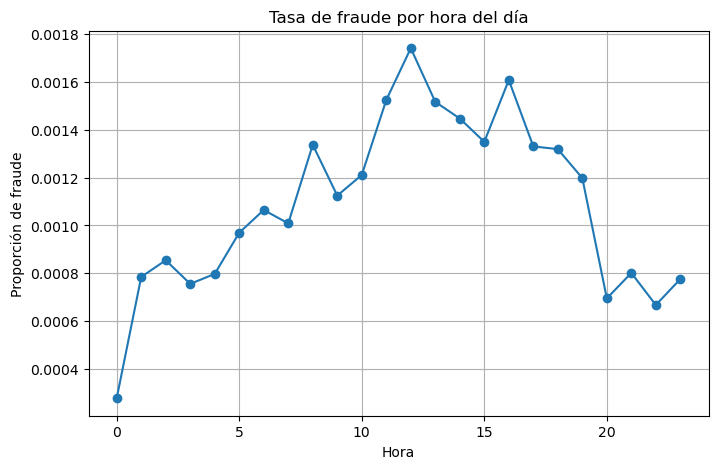

In [28]:
df["hour"] = df["Timestamp"].dt.hour

fraud_hour = df.groupby("hour")["Is Laundering"].mean()

plt.figure(figsize=(8,5))
fraud_hour.plot(marker="o")
plt.title("Tasa de fraude por hora del día")
plt.ylabel("Proporción de fraude")
plt.xlabel("Hora")
plt.grid(True)
plt.show()

### Distribución de puntos entre montos enviados y recibidos.

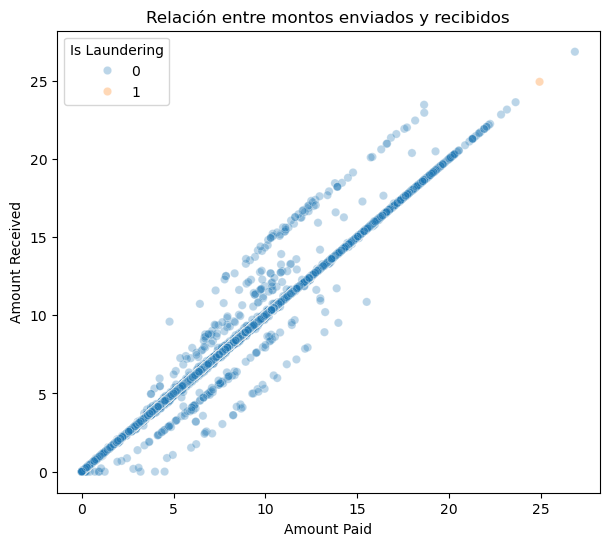

In [29]:
df_sample = df.sample(50000, random_state=42)

plt.figure(figsize=(7,6))
sns.scatterplot(
    x=np.log1p(df_sample["Amount Paid"]),
    y=np.log1p(df_sample["Amount Received"]),
    hue=df_sample["Is Laundering"],
    alpha=0.3
)

plt.title("Relación entre montos enviados y recibidos")
plt.show()

### Box Plot de montos por tipo de pago.

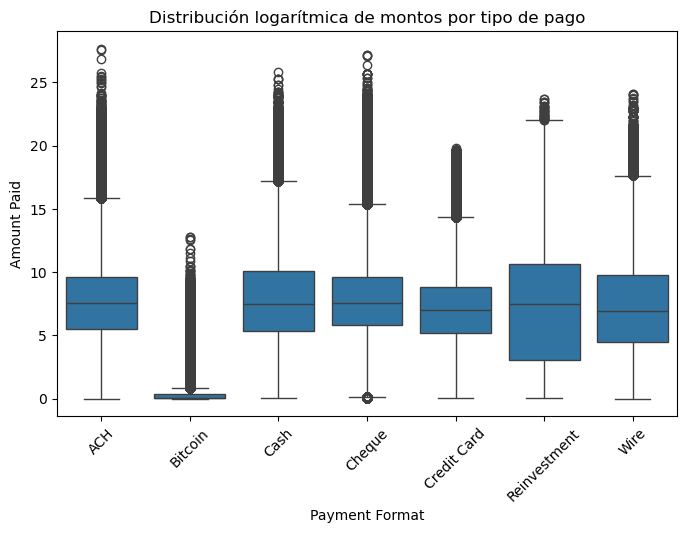

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Payment Format",
    y=np.log1p(df["Amount Paid"]),
    data=df
)

plt.xticks(rotation=45)
plt.title("Distribución logarítmica de montos por tipo de pago")
plt.show()

### Distribución de la variable objetivo

In [31]:
# Distribución absoluta y relativa
print(df["Is Laundering"].value_counts())
print(df["Is Laundering"].value_counts(normalize=True))

Is Laundering
0    5073218
1       5177
Name: count, dtype: int64
Is Laundering
0   1.00
1   0.00
Name: proportion, dtype: float64


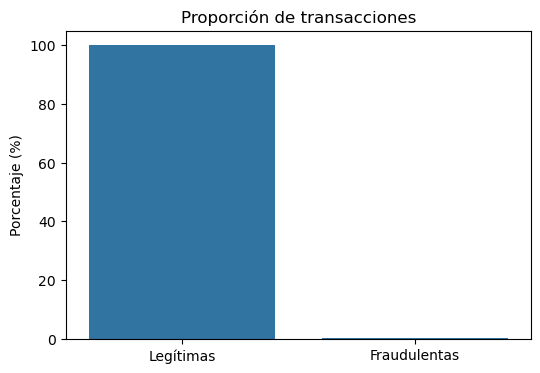

In [32]:
fraud_rate = df["Is Laundering"].mean() * 100
plt.figure(figsize=(6,4))
sns.barplot(x=["Legítimas", "Fraudulentas"],
            y=[100-fraud_rate, fraud_rate])

plt.title("Proporción de transacciones")
plt.ylabel("Porcentaje (%)")
plt.show()

### Distribución de montos.

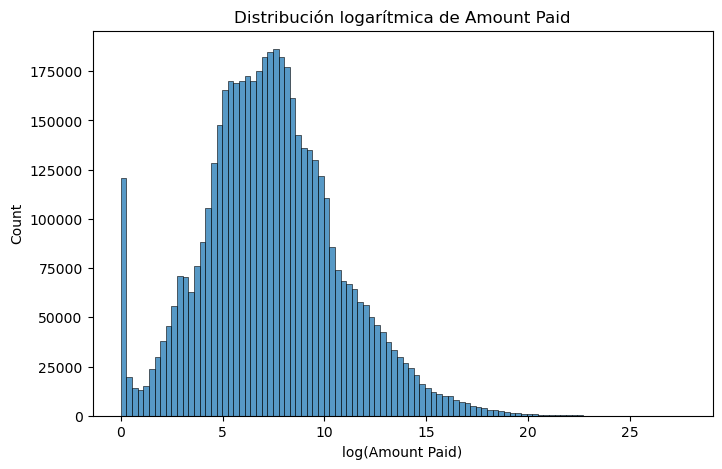

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["Amount Paid"]), bins=100)
plt.title("Distribución logarítmica de Amount Paid")
plt.xlabel("log(Amount Paid)")
plt.show()

### Distribución de montos según clase.

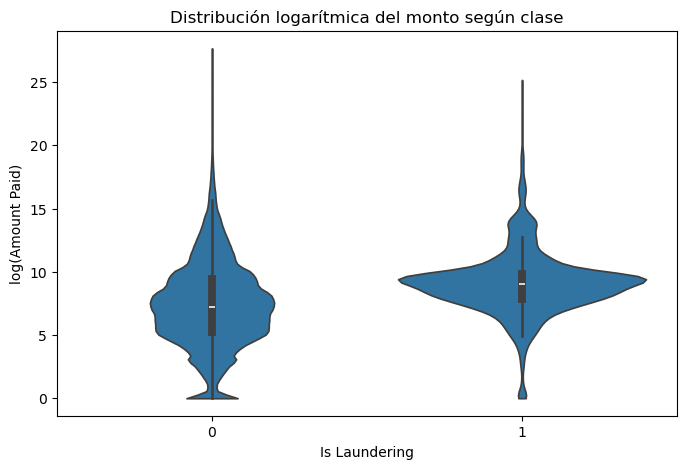

In [34]:
plt.figure(figsize=(8,5))
sns.violinplot(
    x="Is Laundering",
    y=np.log1p(df["Amount Paid"]),
    data=df,
    cut=0
)
plt.title("Distribución logarítmica del monto según clase")
plt.ylabel("log(Amount Paid)")
plt.show()

### Fraude según transacción interbancaria.

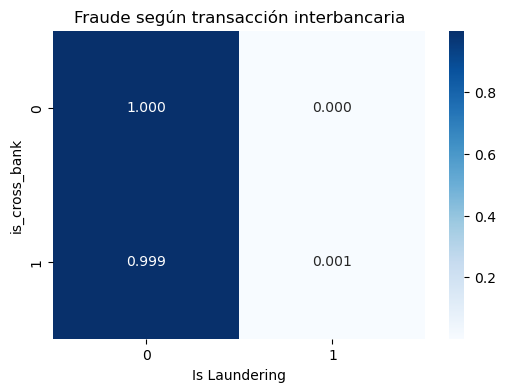

In [35]:
df["is_cross_bank"] = (df["From Bank"] != df["To Bank"]).astype(int)
cross_tab = pd.crosstab(
    df["is_cross_bank"],
    df["Is Laundering"],
    normalize="index"
)

plt.figure(figsize=(6,4))
sns.heatmap(cross_tab, annot=True, fmt=".3f", cmap="Blues")
plt.title("Fraude según transacción interbancaria")
plt.show()

### Transacciones por hora.

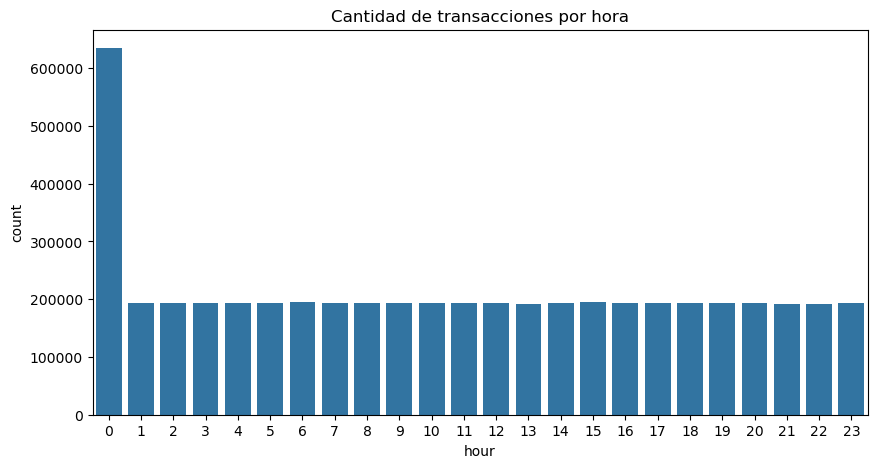

In [36]:
df["hour"] = df["Timestamp"].dt.hour
plt.figure(figsize=(10,5))
sns.countplot(x="hour", data=df)
plt.title("Cantidad de transacciones por hora")
plt.show()

### Tasa de fraude por pago.

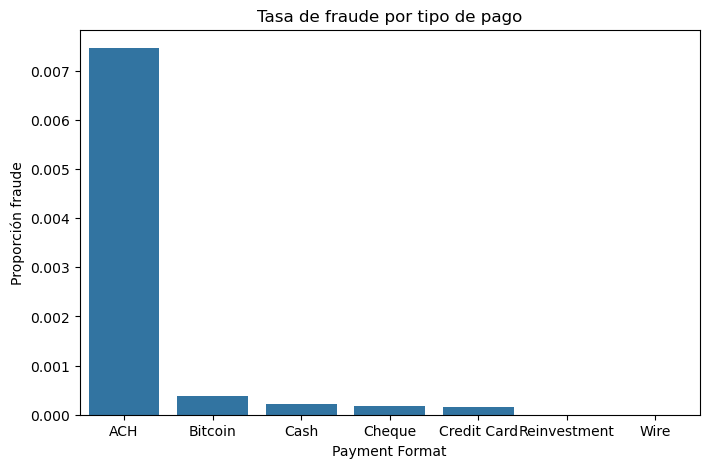

In [37]:
fraud_by_payment = pd.crosstab(
    df["Payment Format"],
    df["Is Laundering"],
    normalize="index"
)

fraud_by_payment = fraud_by_payment.sort_values(by=1, ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(
    x=fraud_by_payment.index,
    y=fraud_by_payment[1]
)
plt.xticks()
plt.title("Tasa de fraude por tipo de pago")
plt.ylabel("Proporción fraude")
plt.show()

### Tasa de fraude diaria.

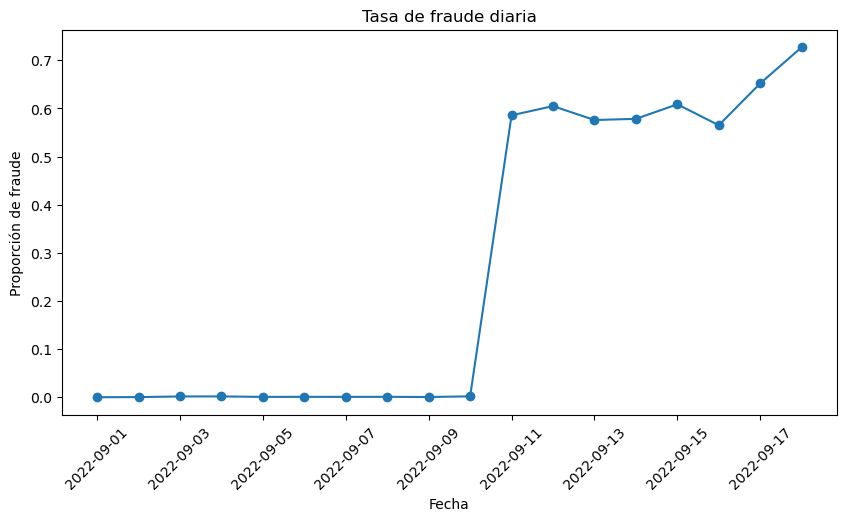

In [38]:
daily_fraud_rate = (
    df
    .groupby(df["Timestamp"].dt.date)["Is Laundering"]
    .mean()
)

plt.figure(figsize=(10,5))
daily_fraud_rate.plot(marker="o")
plt.title("Tasa de fraude diaria")
plt.ylabel("Proporción de fraude")
plt.xlabel("Fecha")
plt.xticks(rotation=45)
plt.show()

### Tasa de fraude por decil de monto.

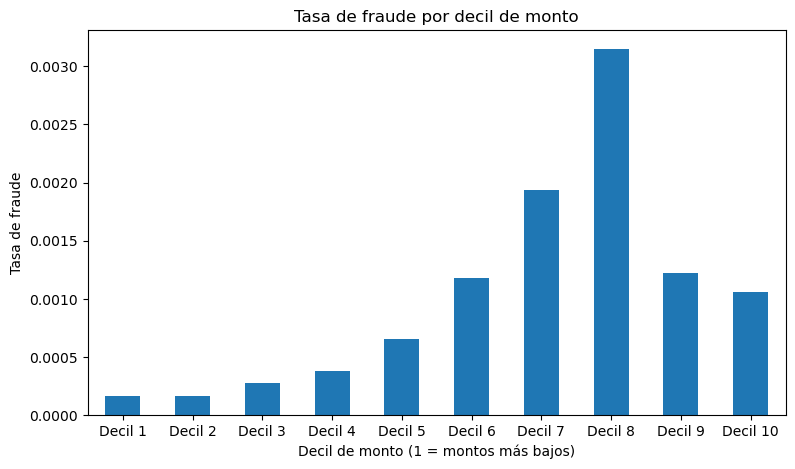

In [39]:
df["amount_bin"] = pd.qcut(
    df["Amount Paid"],
    10,
    labels=[f"Decil {i}" for i in range(1, 11)]
)

fraud_by_bin = (
    df.groupby("amount_bin", observed=True)["Is Laundering"]
    .mean()
)

plt.figure(figsize=(9,5))
fraud_by_bin.plot(kind="bar")

plt.title("Tasa de fraude por decil de monto")
plt.xlabel("Decil de monto (1 = montos más bajos)")
plt.ylabel("Tasa de fraude")
plt.xticks(rotation=0)
plt.show()

### Tasa de fraude por entidad.

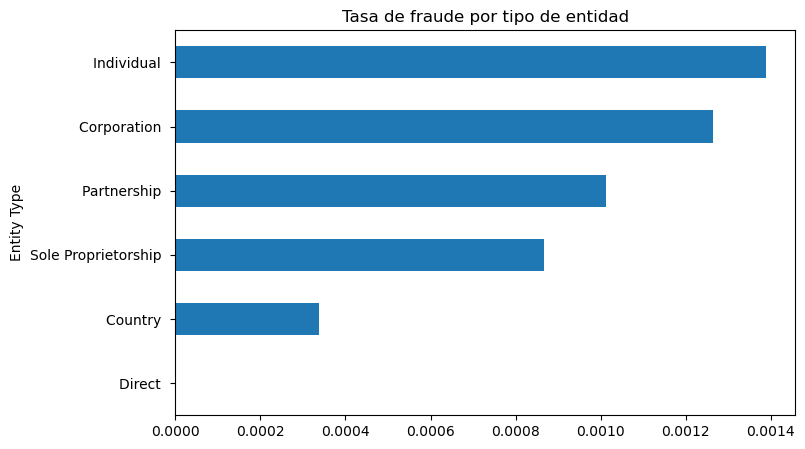

In [40]:
df["Entity Type"] = df["Entity Name"].str.extract(r"([A-Za-z\s]+)")

fraud_entity = df.groupby("Entity Type")["Is Laundering"].mean()

fraud_entity.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Tasa de fraude por tipo de entidad")
plt.show()

---

# 4.6 Conclusiones del EDA.

##### Con el objetivo de comprender la estructura, distribución y comportamiento de las transacciones financieras, se realizó un análisis exploratorio enfocado en la variable objetivo (Is Laundering) y en su relación con variables temporales, monetarias y categóricas.

#### En primer lugar, se observó un fuerte desbalance de clases, donde las transacciones fraudulentas representan aproximadamente el 0.1% del total. Este desbalance es consistente con escenarios reales de detección de fraude y sugiere que será necesario considerar técnicas específicas de modelado (re-muestreo, métricas adecuadas como AUC-PR, etc.) en etapas posteriores.

#### Desde el punto de vista monetario, la distribución de los montos presenta una alta asimetría positiva, con una larga cola derecha que evidencia la presencia de transacciones de gran magnitud. La transformación logarítmica permitió estabilizar la varianza y analizar mejor la distribución. Al comparar montos según clase (violin plot), se observa que las transacciones fraudulentas tienden a concentrarse en rangos de montos ligeramente superiores a los legítimos, aunque con fuerte superposición entre ambas distribuciones.

#### El análisis por deciles de monto mostró un patrón relevante: la tasa de fraude aumenta progresivamente en los deciles medios-altos, alcanzando un máximo en el decil 8, y luego desciende levemente en los deciles más extremos. Esto sugiere que el fraude no necesariamente ocurre en los montos máximos absolutos, sino en rangos intermedios-altos que podrían resultar menos sospechosos operativamente.

#### Desde la dimensión temporal, el análisis horario evidenció que la tasa de fraude no es uniforme a lo largo del día. Se identifican picos relativos en determinadas franjas horarias (especialmente entre media mañana y primeras horas de la tarde), lo que sugiere que el componente temporal puede aportar señal predictiva. A nivel diario, se observa un quiebre estructural a partir del 11 de septiembre, donde la proporción de fraude aumenta considerablemente, lo que podría indicar un cambio de comportamiento o un evento específico en el dataset.

#### En relación con el tipo de pago, el método ACH presenta la mayor tasa relativa de fraude, muy por encima del resto de los medios. Esto lo posiciona como una variable categórica con alto poder explicativo potencial. Otros métodos como Cash, Cheque o Credit Card muestran tasas considerablemente menores.

#### El análisis por tipo de entidad revela diferencias relevantes: las entidades clasificadas como Individual y Corporation presentan tasas de fraude superiores a otros tipos como Sole Proprietorship o Country, lo que sugiere que el perfil de la entidad puede influir en la probabilidad de comportamiento fraudulento.

#### Finalmente, el análisis de transacciones interbancarias indica que las operaciones entre bancos distintos presentan una tasa de fraude levemente superior a las transacciones dentro del mismo banco, aunque la diferencia no es extremadamente marcada.

#### En conjunto, el EDA sugiere que el fraude en este dataset no depende de una única variable aislada, sino que emerge de la combinación de factores monetarios, temporales y categóricos. Variables como, decil de monto, tipo de pago (especialmente ACH), tipo de entidad, hora del día e indicador de transacción interbancaria, muestran patrones diferenciadores que podrían aportar capacidad predictiva en un modelo supervisado. Asimismo, el fuerte desbalance de clases y la presencia de un posible cambio estructural en el tiempo son aspectos críticos que deberán ser considerados en la etapa de modelado.

---

# 4.7 Feature Engineering

### Ordeno por Timestamp

In [41]:
df = df.sort_values("Timestamp").reset_index(drop=True)

### Log del monto

In [42]:
df["log_amount"] = np.log1p(df["Amount Paid"])

### Decil de monto

In [43]:
df["amount_decile"] = pd.qcut(
    df["Amount Paid"],
    10,
    labels=False,
    duplicates="drop"
)

### Indicador de monto alto (percentil 75)

In [44]:
threshold = df["Amount Paid"].quantile(0.75)
df["high_amount"] = (df["Amount Paid"] > threshold).astype(int)

### Hora

In [45]:
df["hour"] = df["Timestamp"].dt.hour

### Franja horaria

In [46]:
def time_bucket(h):
    if 0 <= h < 6:
        return "madrugada"
    elif 6 <= h < 12:
        return "mañana"
    elif 12 <= h < 18:
        return "tarde"
    else:
        return "noche"

df["time_bucket"] = df["hour"].apply(time_bucket)

### Día de la semana

In [47]:
df["weekday"] = df["Timestamp"].dt.weekday

### Indicador post quiebre (11 septiembre)

In [48]:
df["post_break"] = (df["Timestamp"] >= "2022-09-11").astype(int)

### Transacción interbancaria

In [49]:
df["is_cross_bank"] = (df["From Bank"] != df["To Bank"]).astype(int)

### Cantidad de transacciones previas por cuenta

In [50]:
df["tx_count_account"] = df.groupby("Account").cumcount()

### Tiempo desde última transacción en segundos

In [51]:
df["prev_time"] = df.groupby("Account")["Timestamp"].shift(1)
df["time_diff_sec"] = (
    df["Timestamp"] - df["prev_time"]
).dt.total_seconds()

# Reemplazo NaN (primera transacción de cada cuenta)
df["time_diff_sec"] = df["time_diff_sec"].fillna(-1)

### Desviación respecto al promedio histórico de la cuenta

In [52]:
df = df.sort_values(["Account", "Timestamp"])

# Suma acumulada por cuenta
df["cum_amount"] = df.groupby("Account")["Amount Paid"].cumsum()

# Conteo acumulado por cuenta
df["cum_count"] = df.groupby("Account").cumcount() + 1

# Promedio histórico, incluyend transacción actual
df["account_avg_amount"] = df["cum_amount"] / df["cum_count"]

# Desviación respecto al promedio histórico
df["amount_vs_account_avg"] = (
    df["Amount Paid"] / df["account_avg_amount"]
).replace([np.inf, -np.inf], 1).fillna(1)
df.drop(columns=["cum_amount", "cum_count"], inplace=True)

#### Dataset para modelar.

In [53]:
df.shape

(5078395, 31)

In [54]:
pd.set_option("display.max_columns", None)
df.head()


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Bank Name,Bank ID,Account Number,Entity ID,Entity Name,hour,is_cross_bank,amount_bin,Entity Type,log_amount,amount_decile,high_amount,time_bucket,weekday,post_break,tx_count_account,prev_time,time_diff_sec,account_avg_amount,amount_vs_account_avg
304,2022-09-01,70,100428660,11318,80CD01F40,"3,034,485.25",US Dollar,"3,034,485.25",US Dollar,Cheque,0,Oasis Thrift,70,100428660,800B93710,Sole Proprietorship #41,0,1,Decil 10,Sole Proprietorship,14.93,9,1,madrugada,3,0,0,NaT,-1.00,"3,034,485.25",1.00
395,2022-09-01,70,100428660,23885,805DEB4F0,"53,574.59",US Dollar,"53,574.59",US Dollar,Cheque,0,Oasis Thrift,70,100428660,800B93710,Sole Proprietorship #41,0,1,Decil 9,Sole Proprietorship,10.89,8,1,madrugada,3,0,1,2022-09-01,0.00,"1,544,029.88",0.03
651,2022-09-01,70,100428660,3051,81330BC40,602.80,US Dollar,602.80,US Dollar,Cash,0,Oasis Thrift,70,100428660,800B93710,Sole Proprietorship #41,0,1,Decil 4,Sole Proprietorship,6.40,3,0,madrugada,3,0,2,2022-09-01,0.00,"1,029,554.25",0.00
711,2022-09-01,70,100428660,13432,805C61700,"1,057,735.75",US Dollar,"1,057,735.75",US Dollar,Cash,0,Oasis Thrift,70,100428660,800B93710,Sole Proprietorship #41,0,1,Decil 10,Sole Proprietorship,13.87,9,1,madrugada,3,0,3,2022-09-01,0.00,"1,036,599.62",1.02
958,2022-09-01,70,100428660,-19441,8135175D0,"4,985,152.00",US Dollar,"4,985,152.00",US Dollar,Cash,0,Oasis Thrift,70,100428660,800B93710,Sole Proprietorship #41,0,1,Decil 10,Sole Proprietorship,15.42,9,1,madrugada,3,0,4,2022-09-01,0.00,"1,826,310.00",2.73


---

# 4.8 Conclusión Feature Engineering

#### Con el objetivo de capturar patrones estructurales asociados al comportamiento transaccional, se realizó una etapa de ingeniería de variables orientada a enriquecer la capacidad predictiva del modelo. En primer lugar, se transformó el monto mediante una escala logarítmica para estabilizar su varianza y reducir el impacto de valores extremos. Se incorporaron variables de segmentación como el decil de monto y un indicador de montos elevados, permitiendo modelar comportamientos diferenciados según magnitud de la transacción. Asimismo, se generaron variables temporales tales como hora del día, franja horaria, día de la semana e indicador posterior a un punto de quiebre detectado en el EDA, capturando posibles cambios estructurales en la dinámica del fraude.
#### Adicionalmente, se incluyeron variables conductuales por cuenta, como la cantidad acumulada de transacciones previas, el tiempo transcurrido desde la última operación y la desviación del monto respecto al promedio histórico de la cuenta. Finalmente, se incorporó un indicador de transacción interbancaria para modelar diferencias operativas entre movimientos internos y externos. Estas transformaciones permiten representar no solo características individuales de cada transacción, sino también patrones dinámicos y contextuales, fundamentales en problemas de detección de fraude.

---

# 4.9 Limpieza, separación de variables y método dummy

### Limpieza de variables.

In [55]:
cols_to_drop = [
    "Timestamp",
    "Account",
    "Account.1",
    "Bank Name",
    "Bank ID",
    "Account Number",
    "Entity ID",
    "Entity Name",
    "prev_time",
]

df_model = df.drop(columns=cols_to_drop)

### Separo features y target

In [56]:
X = df_model.drop(columns=["Is Laundering"])
y = df_model["Is Laundering"]

### Transformo variables categóricas.

In [57]:
X = pd.get_dummies(X, drop_first=True)

---

## 4.10 Conclusión previa a Split

#### En esta etapa se realizó la depuración final del dataset con el objetivo de preparar la información para el entrenamiento de modelos supervisados. En primer lugar, se eliminaron aquellas columnas que no aportan valor predictivo o que corresponden a identificadores administrativos, tales como IDs de cuentas, bancos, entidades y marcas temporales originales, evitando así introducir ruido o posibles fuentes de fuga de información en el modelo.
#### Posteriormente, se procedió a la separación entre variables predictoras (X) y variable objetivo (y), definiendo como target la variable Is Laundering, la cual indica si una transacción está asociada a lavado de dinero (1) o no (0). Esta separación permite garantizar que las transformaciones posteriores se apliquen exclusivamente sobre las variables explicativas, preservando la integridad de la variable objetivo.
#### Finalmente, se aplicó el método de codificación dummy (One-Hot Encoding) sobre las variables categóricas, tales como el tipo de pago, tipo de entidad y franja horaria. Esta transformación convierte variables categóricas en representaciones numéricas binarias, requisito necesario para su correcta utilización en modelos de machine learning. El uso de codificación dummy permite capturar información categórica sin imponer relaciones ordinales artificiales entre categorías.

---

# 4.11 Split estratificado

#### Dado que el problema abordado corresponde a una clasificación binaria altamente desbalanceada, donde las transacciones fraudulentas representan una proporción muy reducida del total, se optó por dividir el dataset en conjuntos de entrenamiento y prueba utilizando un esquema de partición estratificada. La estratificación asegura que la proporción de clases (fraude y no fraude) se mantenga consistente en ambos subconjuntos, evitando escenarios en los que el conjunto de prueba contenga una representación no adecuada del fenómeno de interés. Se utilizó una división estándar 80/20 entre entrenamiento y test, permitiendo entrenar el modelo con suficiente información histórica y evaluar su desempeño en datos no vistos previamente

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

---

# 4.12 Modelo Regresión Logística

#### La Regresión Logística es un modelo estadístico de clasificación supervisada ampliamente utilizado en problemas de detección de fraude debido a su solidez teórica e interpretabilidad. A diferencia de la regresión lineal, la Regresión Logística modela la probabilidad de pertenencia a una clase mediante la función logística (sigmoide), la cual transforma una combinación lineal de variables explicativas en un valor comprendido entre 0 y 1. Esto permite interpretar el resultado como la probabilidad estimada de que una transacción esté asociada a lavado de dinero. El modelo estima los coeficientes mediante máxima verosimilitud, buscando maximizar la probabilidad de observar las clases reales dadas las variables predictoras.

In [59]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)

In [60]:
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

In [61]:
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

---

# 4.13 Evaluación en test

#### Para evaluar el desempeño predictivo del modelo se utilizaron métricas adecuadas para problemas de clasificación desbalanceada, tales como ROC-AUC y PR-AUC, complementadas con el classification report (precision, recall y F1-score). La utilización conjunta de estas métricas permite analizar la capacidad discriminatoria global del modelo (ROC-AUC), su comportamiento frente a la clase minoritaria (PR-AUC) y el equilibrio entre precisión y sensibilidad en la detección de transacciones fraudulentas.

In [62]:
roc = roc_auc_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

print("ROC AUC:", roc)
print("PR AUC:", pr_auc)

ROC AUC: 0.643337322833794
PR AUC: 0.008131578312054296


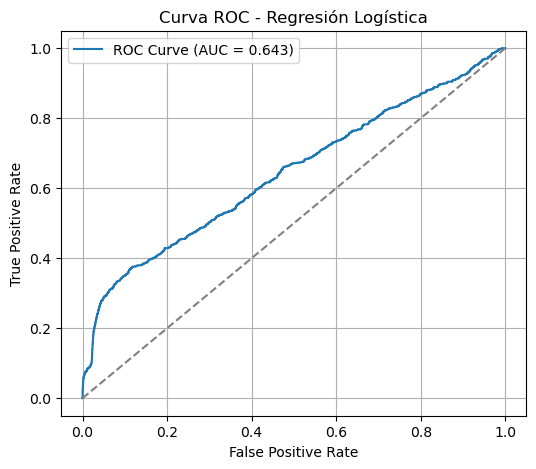

In [63]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.48      0.64   1014644
           1       0.00      0.68      0.00      1035

    accuracy                           0.48   1015679
   macro avg       0.50      0.58      0.32   1015679
weighted avg       1.00      0.48      0.64   1015679



---

# 4.14 Conclusión de Regresión Logística.

#### La Regresión Logística logra una capacidad discriminatoria moderada, evidenciada por un valor intermedio de ROC-AUC. Si bien el modelo identifica cierta estructura separable entre transacciones legítimas y fraudulentas, su desempeño se ve afectado por el fuerte desbalance de clases, lo que impacta especialmente en la precisión sobre la clase minoritaria. Estos resultados indican que, aunque la Regresión Logística constituye un baseline sólido y fácilmente interpretable, presenta limitaciones para capturar patrones complejos y no lineales en los datos. En consecuencia, resulta pertinente evaluar modelos más flexibles, como Random Forest o LightGBM, que potencialmente puedan mejorar la capacidad predictiva en un contexto de fraude altamente desbalanceado.

---

# 4.15 Modelo Random Forest.

#### El Random Forest es un modelo de aprendizaje automático supervisado basado en el ensamble de múltiples árboles de decisión, ampliamente utilizado en problemas de clasificación como la detección de fraude debido a su capacidad para capturar relaciones no lineales y patrones complejos en los datos. A diferencia de un único árbol de decisión, que puede presentar alta varianza y riesgo de sobreajuste, Random Forest construye numerosos árboles sobre distintas muestras aleatorias del conjunto de entrenamiento (bootstrap) y combina sus predicciones mediante votación mayoritaria. Además, en cada división de nodo se selecciona aleatoriamente un subconjunto de variables, lo que introduce mayor diversidad entre los árboles y mejora la robustez del modelo.

In [65]:
X_sample = X_train.sample(500000, random_state=42)
y_sample = y_train.loc[X_sample.index]

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

In [66]:
rf.fit(X_sample, y_sample)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=5, min_samples_split=10, n_jobs=-1,
                       random_state=42)

In [67]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

---

# 4.16 Evaluación de metricas en Random Forest.

In [68]:
roc_rf = roc_auc_score(y_test, y_proba_rf)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
pr_auc_rf = auc(recall_rf, precision_rf)

print("ROC AUC:", roc_rf)
print("PR AUC:", pr_auc_rf)

ROC AUC: 0.9436907234801395
PR AUC: 0.0686634014375397


In [69]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1014644
           1       0.03      0.62      0.06      1035

    accuracy                           0.98   1015679
   macro avg       0.52      0.80      0.53   1015679
weighted avg       1.00      0.98      0.99   1015679



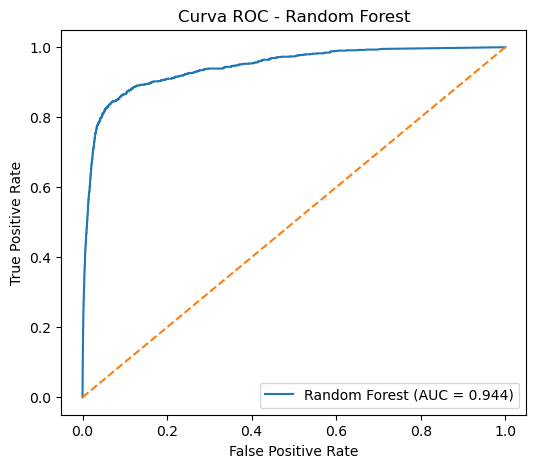

In [70]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_rf:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.show()

---

## 4.17 Conclusión Random Forest.

#### El modelo Random Forest permite capturar relaciones no lineales e interacciones complejas entre las variables, lo cual resulta especialmente relevante en problemas de detección de fraude, donde los patrones suelen ser heterogéneos y difíciles de modelar con enfoques lineales. Al combinar múltiples árboles de decisión entrenados sobre subconjuntos aleatorios de los datos y variables, el modelo logra una mayor robustez y capacidad de generalización frente a escenarios con alta variabilidad. En comparación con modelos más simples, Random Forest muestra una mejora sustancial en la capacidad de discriminación entre transacciones legítimas y fraudulentas, especialmente en términos de identificación de eventos poco frecuentes. No obstante, la naturaleza altamente desbalanceada del problema continúa representando un desafío, particularmente en la precisión sobre la clase minoritaria. En conjunto, el modelo constituye una base sólida y más potente que enfoques lineales, aunque aún existen oportunidades de mejora mediante técnicas adicionales de optimización o modelos basados en boosting.

---

# 4.18 Modelo LightGBM.

#### LightGBM es un modelo de aprendizaje automático basado en la técnica de gradient boosting, diseñado para construir modelos predictivos de alta precisión de manera eficiente y escalable. A diferencia de Random Forest, que entrena múltiples árboles de forma independiente y combina sus resultados por votación, LightGBM construye árboles secuencialmente, donde cada nuevo árbol busca corregir los errores cometidos por los anteriores. Este enfoque permite capturar patrones complejos y mejorar progresivamente el desempeño del modelo.

In [71]:
lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [72]:
lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4142, number of negative: 4058574
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.114398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2444
[LightGBM] [Info] Number of data points in the train set: 4062716, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, n_estimators=300, n_jobs=-1, random_state=42,
               subsample=0.8)

In [73]:
y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

---

# 4.19 Evaluación con las mismas métricas

In [74]:
roc_lgb = roc_auc_score(y_test, y_proba_lgb)

precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, y_proba_lgb)
pr_auc_lgb = auc(recall_lgb, precision_lgb)

print("ROC AUC:", roc_lgb)
print("PR AUC:", pr_auc_lgb)

ROC AUC: 0.9820480201932561
PR AUC: 0.3028912907199627


In [75]:
print(classification_report(y_test, y_pred_lgb))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96   1014644
           1       0.01      0.91      0.03      1035

    accuracy                           0.93   1015679
   macro avg       0.51      0.92      0.50   1015679
weighted avg       1.00      0.93      0.96   1015679



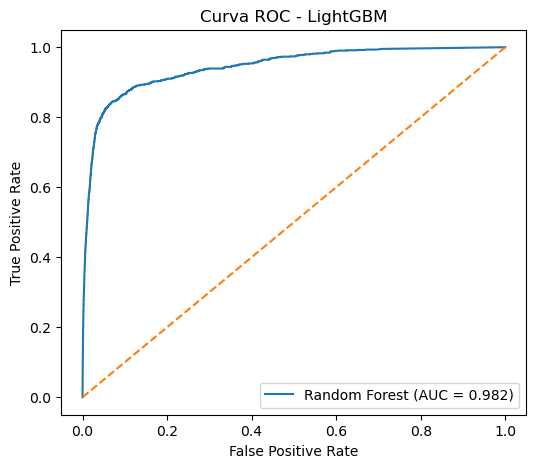

In [76]:
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_lgb:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - LightGBM")
plt.legend()
plt.show()

---

# 4.20 Conclusión LightGBM

#### El modelo LightGBM muestra una elevada capacidad de discriminación entre transacciones legítimas y fraudulentas, logrando una separación más marcada entre clases en comparación con los modelos anteriores. Su enfoque basado en boosting le permite capturar patrones complejos y relaciones no lineales presentes en los datos, lo que se traduce en una mejora sustancial en la detección de la clase minoritaria. Sin embargo, al igual que en los otros modelos evaluados, persiste el desafío inherente al fuerte desbalance del dataset, lo que impacta en la precisión de las predicciones positivas. Aun así, el comportamiento general del modelo sugiere que constituye la alternativa más sólida dentro del conjunto analizado, especialmente en términos de capacidad para identificar eventos de fraude, consolidándose como el candidato más prometedor para futuras etapas de ajuste y optimización.

# 4.21 Busco el mejor threshold

In [77]:
thresholds = np.arange(0.01, 0.5, 0.01)

results = []

for t in thresholds:
    y_pred_t = (y_proba_lgb >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append((t, precision, recall, f1))

df_thresholds = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])

In [78]:
# Elijo el threshold óptimo
best_row = df_thresholds.sort_values("f1", ascending=False).iloc[0]
best_threshold = best_row["threshold"]

In [79]:
# Evaluación final
y_pred_final = (y_proba_lgb >= best_threshold).astype(int)

In [80]:
print("Threshold óptimo:", best_threshold)
print(classification_report(y_test, y_pred_final))

Threshold óptimo: 0.49
              precision    recall  f1-score   support

           0       1.00      0.93      0.96   1014644
           1       0.01      0.91      0.03      1035

    accuracy                           0.93   1015679
   macro avg       0.51      0.92      0.49   1015679
weighted avg       1.00      0.93      0.96   1015679



# 4.22 Aplico scale_pos_weight

#### Se utilizó el parámetro scale_pos_weight, calculado como la proporción entre la cantidad de clases negativas y positivas, con el objetivo de penalizar en mayor medida los errores sobre la clase minoritaria y mejorar su capacidad de detección.”

In [81]:
scale_pos_weight = 4058574 / 4142

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [82]:
lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4142, number of negative: 4058574
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.109166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2444
[LightGBM] [Info] Number of data points in the train set: 4062716, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001020 -> initscore=-6.887408
[LightGBM] [Info] Start training from score -6.887408


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               n_jobs=-1, random_state=42, scale_pos_weight=979.8585224529213,
               subsample=0.8)

In [83]:
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

In [84]:
thresholds = np.arange(0.01, 0.5, 0.01)

results = []

for t in thresholds:
    y_pred_t = (y_proba_lgb >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append((t, precision, recall, f1))

df_thresholds = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])

In [85]:
best_row = df_thresholds.sort_values("f1", ascending=False).iloc[0]
best_threshold = best_row["threshold"]

print("Mejor threshold encontrado:")
print(best_row)

Mejor threshold encontrado:
threshold   0.49
precision   0.01
recall      0.85
f1          0.02
Name: 48, dtype: float64


In [86]:
y_pred_final = (y_proba_lgb >= best_threshold).astype(int)

print("Threshold óptimo:", best_threshold)
print(classification_report(y_test, y_pred_final))

Threshold óptimo: 0.49
              precision    recall  f1-score   support

           0       1.00      0.89      0.94   1014644
           1       0.01      0.85      0.02      1035

    accuracy                           0.89   1015679
   macro avg       0.50      0.87      0.48   1015679
weighted avg       1.00      0.89      0.94   1015679



# 4.23 Aplico SMOTE

In [87]:
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

lgb_model.fit(X_res, y_res)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 405857, number of negative: 4058574
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.325150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2444
[LightGBM] [Info] Number of data points in the train set: 4464431, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090909 -> initscore=-2.302586
[LightGBM] [Info] Start training from score -2.302586


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               n_jobs=-1, random_state=42, scale_pos_weight=979.8585224529213,
               subsample=0.8)

In [88]:
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

In [89]:
thresholds = np.arange(0.01, 0.5, 0.01)

results = []

for t in thresholds:
    y_pred_t = (y_proba_lgb >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append((t, precision, recall, f1))

df_thresholds = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])

In [90]:
best_row = df_thresholds.sort_values("f1", ascending=False).iloc[0]
best_threshold = best_row["threshold"]

print("Mejor threshold encontrado:")
print(best_row)

Mejor threshold encontrado:
threshold   0.49
precision   0.01
recall      0.95
f1          0.02
Name: 48, dtype: float64


In [91]:
y_pred_final = (y_proba_lgb >= best_threshold).astype(int)

print("Threshold óptimo:", best_threshold)
print(classification_report(y_test, y_pred_final))

Threshold óptimo: 0.49
              precision    recall  f1-score   support

           0       1.00      0.88      0.94   1014644
           1       0.01      0.95      0.02      1035

    accuracy                           0.88   1015679
   macro avg       0.50      0.91      0.48   1015679
weighted avg       1.00      0.88      0.94   1015679



# 4.24 Conclusión de mejoras

#### El modelo LightGBM presenta una elevada capacidad de discriminación global entre clases, lo cual se evidencia en métricas como el ROC AUC. Asimismo, logra identificar una gran proporción de los casos positivos (alta sensibilidad o recall), lo que indica que es efectivo para detectar la mayoría de los eventos de interés.
#### Sin embargo, se observa una muy baja precisión en la clase minoritaria, lo que implica que una gran cantidad de las predicciones positivas corresponden en realidad a falsos positivos. Este comportamiento es típico en problemas con fuerte desbalance de clases, donde el modelo tiende a sobrepredecir la clase minoritaria al intentar maximizar la detección de estos casos.
#### Con el objetivo de mejorar este comportamiento, se implementaron distintas estrategias. En primer lugar, se optimizó el threshold de decisión evaluando múltiples valores y seleccionando aquel que maximiza el F1-score, buscando un mejor equilibrio entre precision y recall. Adicionalmente, se incorporó el parámetro scale_pos_weight para penalizar en mayor medida los errores sobre la clase minoritaria, y se aplicó la técnica de oversampling mediante SMOTE para balancear el dataset generando ejemplos sintéticos de la clase positiva.
#### A pesar de estos esfuerzos, las mejoras en la precisión fueron limitadas, lo que sugiere que el problema no radica únicamente en el desbalance o en el umbral de clasificación, sino en la capacidad del modelo para generar probabilidades suficientemente discriminativas entre clases. En otras palabras, existe una superposición significativa en las características de ambas clases, lo que dificulta su correcta separación.

---

# 5. Conclusión General del Trabajo

#### El presente trabajo abordó el problema de detección de transacciones asociadas a lavado de dinero a partir de un dataset transaccional de gran escala y fuertemente desbalanceado. Se aplicaron y compararon tres enfoques de clasificación supervisada: un modelo lineal interpretable (Regresión Logística), un modelo basado en ensamble de árboles (Random Forest) y un modelo de boosting de gradiente (LightGBM). Todos los modelos fueron evaluados bajo un mismo esquema de partición estratificada y utilizando métricas consistentes como ROC AUC, Precision-Recall AUC y el classification report, lo que permitió realizar una comparación objetiva de su desempeño.
#### La Regresión Logística funcionó como modelo base, aportando interpretabilidad y una referencia clara del comportamiento del problema. Si bien logró capturar ciertas relaciones entre las variables explicativas y la probabilidad de fraude, su naturaleza lineal limita su capacidad para modelar interacciones complejas y patrones no lineales presentes en los datos transaccionales. En un contexto de fuerte desbalance, este tipo de modelo tiende a mostrar restricciones en la identificación precisa de la clase minoritaria.
#### El modelo Random Forest mejoró sustancialmente la capacidad de captura de patrones complejos gracias a su estructura basada en múltiples árboles de decisión. Al combinar diferentes particiones del espacio de variables y reducir la varianza mediante agregación, logró una separación más robusta entre clases. No obstante, aunque incrementa la flexibilidad respecto al modelo lineal, sigue dependiendo de una construcción estática del ensamble, lo que puede limitar su capacidad de adaptación frente a patrones extremadamente sutiles o dinámicos en problemas altamente desbalanceados.
#### Por su parte, LightGBM se posiciona como el modelo más sólido dentro de los evaluados. Su enfoque de boosting permite un aprendizaje secuencial que corrige errores previos y enfatiza la detección de casos más difíciles, lo que resulta especialmente valioso en problemas de fraude donde la clase positiva es escasa y crítica. Además, su eficiencia computacional y su capacidad para manejar grandes volúmenes de datos lo convierten en una alternativa adecuada para entornos productivos.
#### En términos generales, los resultados evidencian que, a medida que aumenta la complejidad y flexibilidad del modelo, mejora la capacidad para capturar estructuras no lineales y relaciones de alto orden presentes en el comportamiento transaccional. Sin embargo, también se confirma que el desbalance extremo continúa siendo el principal desafío del problema, afectando particularmente la precisión de la clase minoritaria.
#### En conclusión, si bien los tres enfoques aportan valor analítico y permiten comprender distintas perspectivas del problema, LightGBM emerge como la alternativa más prometedora para la detección de fraude en este contexto, combinando capacidad predictiva, adaptabilidad y escalabilidad. Random Forest constituye una alternativa robusta y estable, mientras que la Regresión Logística aporta interpretabilidad y funciona como baseline conceptual del trabajo.